# VP-SDE

--- Initializing VP-SDE ---
[DSM] Epoch 1/25 - Loss: 0.914469
[DSM] Epoch 2/25 - Loss: 0.657895
[DSM] Epoch 3/25 - Loss: 0.531751
[DSM] Epoch 4/25 - Loss: 0.439298
[DSM] Epoch 5/25 - Loss: 0.399224
[DSM] Epoch 6/25 - Loss: 0.389195
[DSM] Epoch 7/25 - Loss: 0.383783
[DSM] Epoch 8/25 - Loss: 0.385147
[DSM] Epoch 9/25 - Loss: 0.379844
[DSM] Epoch 10/25 - Loss: 0.380383
[DSM] Epoch 11/25 - Loss: 0.376641
[DSM] Epoch 12/25 - Loss: 0.377595
[DSM] Epoch 13/25 - Loss: 0.369927
[DSM] Epoch 14/25 - Loss: 0.373682
[DSM] Epoch 15/25 - Loss: 0.371668
[DSM] Epoch 16/25 - Loss: 0.370815
[DSM] Epoch 17/25 - Loss: 0.372710
[DSM] Epoch 18/25 - Loss: 0.369704
[DSM] Epoch 19/25 - Loss: 0.376681
[DSM] Epoch 20/25 - Loss: 0.369047
[DSM] Epoch 21/25 - Loss: 0.372011
[DSM] Epoch 22/25 - Loss: 0.371971
[DSM] Epoch 23/25 - Loss: 0.373506
[DSM] Epoch 24/25 - Loss: 0.370025
[DSM] Epoch 25/25 - Loss: 0.371576
--- Initializing VP-SDE ---
Model successfully loaded from checkpoint.


/var/folders/sx/y6c6vjtn04719m5bcb52hk3r0000gn/T/ipykernel_1375/143736268.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_pa

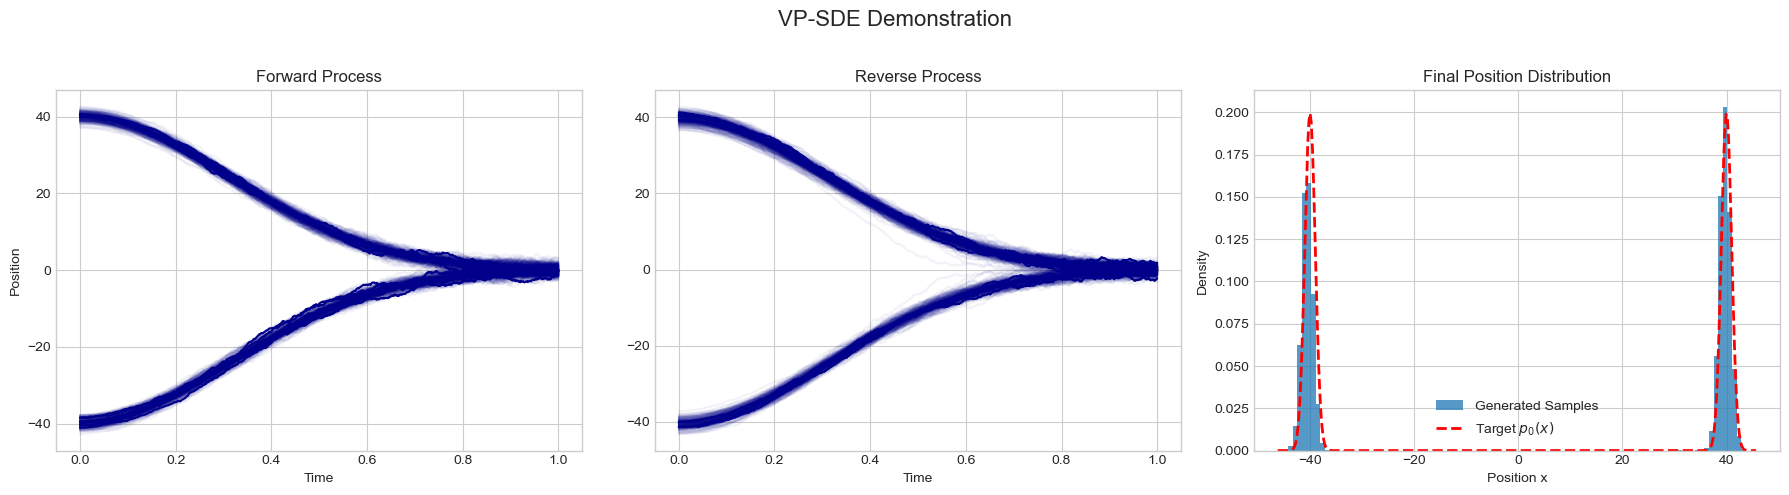

In [ ]:
import os
import torch
import matplotlib.pyplot as plt
from models import ScoreNetwork
from diffusion.vpsde import VPSDE
DEVICE = torch.device("cpu")  # or "cuda" if you trained on GPU

GMM_PARAMS = {
    'weights': [0.5, 0.5],
    'means': [-40., 40.],
    'stds': [1., 1.]
}
vpsde = VPSDE(GMM_PARAMS)

train = True
if train:
    # Train
    model, losses = vpsde.train_score_network_dsm(n_epochs=25, batch_size=128)

    # Save model
    save_dir = "checkpoints/vpsde"
    os.makedirs(save_dir, exist_ok=True)
    torch.save(model.state_dict(), os.path.join(save_dir, "score_net_final.pt"))

    # Save loss plot
    plt.figure(figsize=(8,5))
    plt.plot(range(1, len(losses)+1), losses, lw=2)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Score Network Training Loss")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(save_dir, "training_loss.png"))
    plt.close()


checkpoint_path = f"{save_dir}/score_net_final.pt"
model = ScoreNetwork().to(DEVICE)
model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
model.eval()
print("Model successfully loaded from checkpoint.")
n_plot, n_hist = 500, 10000
model.eval()
vpsde.run_demonstration(n_plot, n_hist, score_model=model)

# CLD

--- Initializing Critically Damped Langevin ---
[HSM] Epoch 1/25 - Loss: 0.120128
[HSM] Epoch 2/25 - Loss: 0.068654
[HSM] Epoch 3/25 - Loss: 0.060056
[HSM] Epoch 4/25 - Loss: 0.057003
[HSM] Epoch 5/25 - Loss: 0.058268
[HSM] Epoch 6/25 - Loss: 0.051499
[HSM] Epoch 7/25 - Loss: 0.054291
[HSM] Epoch 8/25 - Loss: 0.048980
[HSM] Epoch 9/25 - Loss: 0.047239
[HSM] Epoch 10/25 - Loss: 0.049179
[HSM] Epoch 11/25 - Loss: 0.045208
[HSM] Epoch 12/25 - Loss: 0.044945
[HSM] Epoch 13/25 - Loss: 0.046079
[HSM] Epoch 14/25 - Loss: 0.045219
[HSM] Epoch 15/25 - Loss: 0.043689
[HSM] Epoch 16/25 - Loss: 0.044920
[HSM] Epoch 17/25 - Loss: 0.044929
[HSM] Epoch 18/25 - Loss: 0.041358
[HSM] Epoch 19/25 - Loss: 0.044597
[HSM] Epoch 20/25 - Loss: 0.044516
[HSM] Epoch 21/25 - Loss: 0.042126
[HSM] Epoch 22/25 - Loss: 0.045461
[HSM] Epoch 23/25 - Loss: 0.043486
[HSM] Epoch 24/25 - Loss: 0.041414
[HSM] Epoch 25/25 - Loss: 0.044858
Training complete. Model + loss plot saved in checkpoints/cld


/var/folders/sx/y6c6vjtn04719m5bcb52hk3r0000gn/T/ipykernel_8915/2468116206.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_p

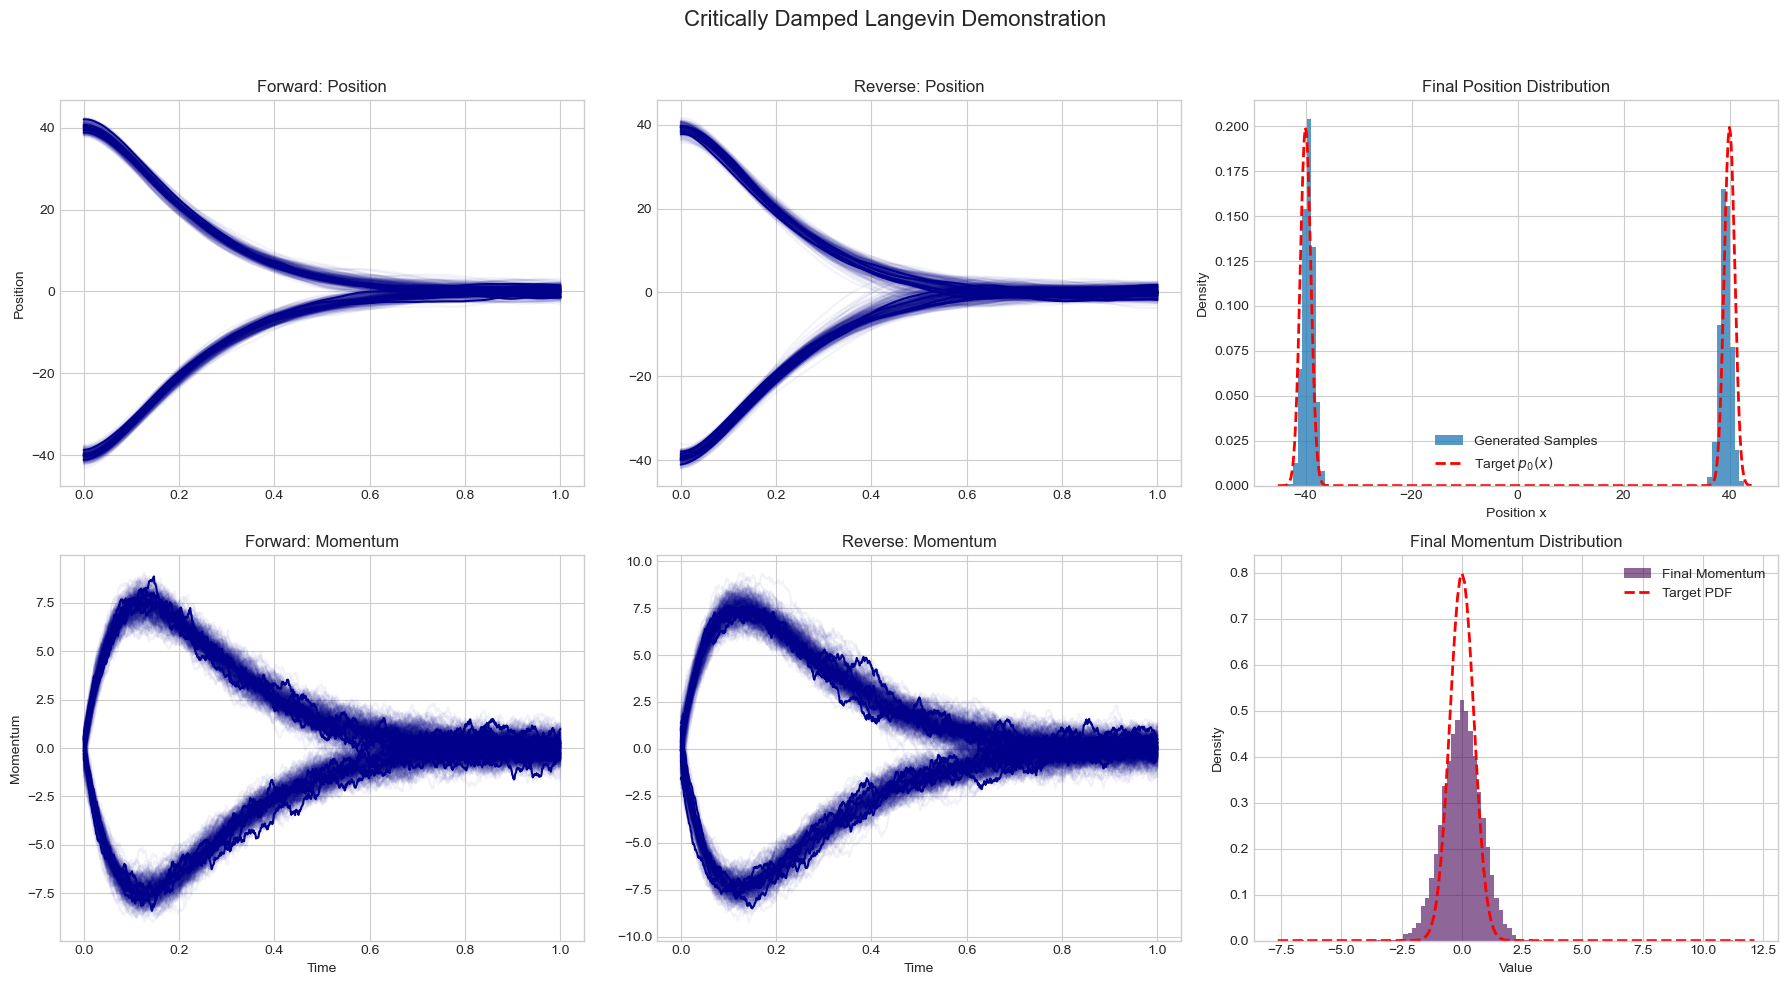

In [1]:
import os
import torch
import matplotlib.pyplot as plt
from diffusion.cld import CriticallyDampedLangevin
from models import CLDScoreNetwork
DEVICE = torch.device("cpu")  # or "cuda" if you trained on GPU

GMM_PARAMS = {
    'weights': [0.5, 0.5],
    'means': [-40., 40.],
    'stds': [1., 1.]
}

# Initialize CLD
cld = CriticallyDampedLangevin(GMM_PARAMS)
save_dir = "checkpoints/cld"
train = True
if train:
    # Train with Hybrid Score Matching
    model, losses = cld.train_score_network_hsm(
        CLDScoreNetwork, n_epochs=25, batch_size=128, lr=1e-3
    )

    # Save model + training loss
    os.makedirs(save_dir, exist_ok=True)
    torch.save(model.state_dict(), os.path.join(save_dir, "score_net_final.pt"))

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(losses)+1), losses, lw=2)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("CLD Hybrid Score Matching Loss")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(save_dir, "training_loss.png"))
    plt.close()

    print("Training complete. Model + loss plot saved in", save_dir)

checkpoint_path = f"{save_dir}/score_net_final.pt"
model = CLDScoreNetwork().to(DEVICE)
n_plot, n_hist = 500, 10000
model.eval()
model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
cld.run_demonstration(n_plot, n_hist, score_model=model)  # Learned

# GLD

--- Initializing Generalized Langevin Diffusion ---
Checkpoint loaded successfully.


/var/folders/sx/y6c6vjtn04719m5bcb52hk3r0000gn/T/ipykernel_8180/2514188981.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(check

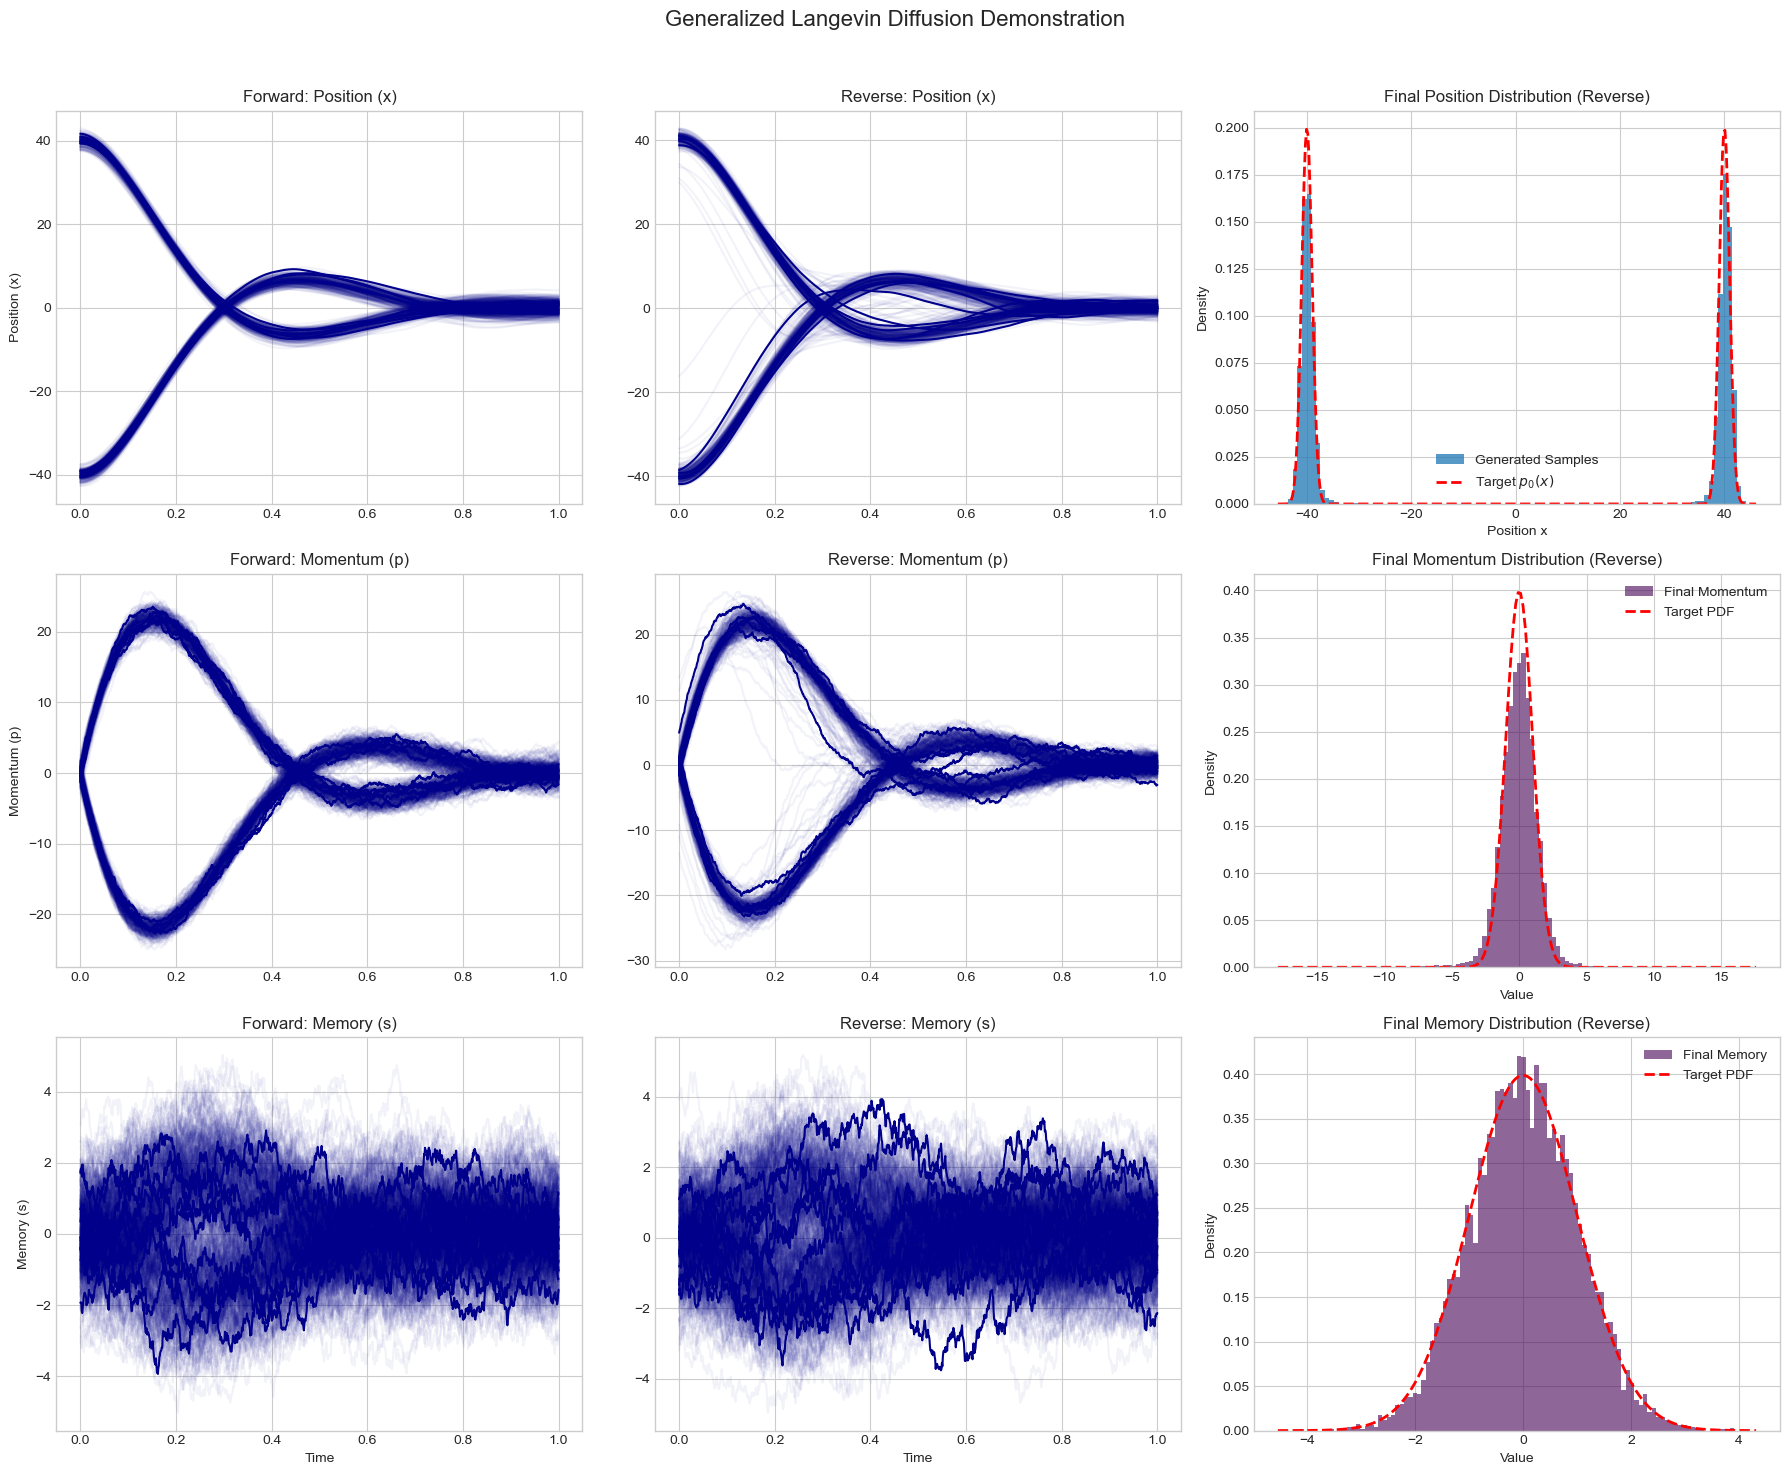

In [ ]:
import os
import torch
import matplotlib.pyplot as plt
from diffusion.gld import GeneralizedLangevinDiffusion
from models import GLDScoreNetwork

# --- Define Gaussian Mixture Model (GMM) parameters ---
GMM_PARAMS = {
    "weights": [0.5, 0.5],
    "means": [-40., 40.],
    "stds": [1., 1.]
}
n_plot, n_hist = 500, 10000

# --- Initialize GLD ---
gld = GeneralizedLangevinDiffusion(GMM_PARAMS, inttype= 'sscs')
save_dir = "checkpoints/gld"
checkpoint_path = f"{save_dir}/score_net_final.pt"
train = False
if train:
    os.makedirs(save_dir, exist_ok=True)
    model, losses = gld.train_score_network_hsm(
        GLDScoreNetwork, n_epochs=25, batch_size=128, lr=1e-4
    )

    torch.save(model.state_dict(), checkpoint_path)

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(losses)+1), losses, lw=2)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("GLD Hybrid Score Matching Loss")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(save_dir, "training_loss.png"))
    plt.close()

    print("Training complete. Model + loss plot saved in", save_dir)
    
loaded_model = GLDScoreNetwork()
loaded_model.load_state_dict(torch.load(checkpoint_path))
loaded_model.eval()

print("Checkpoint loaded successfully.")

_ = gld.run_demonstration(n_plot, n_hist, score_model=loaded_model)

/opt/anaconda3/lib/python3.11/site-packages/scipy/linalg/_solvers.py:193: RuntimeWarning: Input "a" has an eigenvalue pair whose sum is very close to or exactly zero. The solution is obtained via perturbing the coefficients.
  warnings.warn('Input "a" has an eigenvalue pair whose sum is '


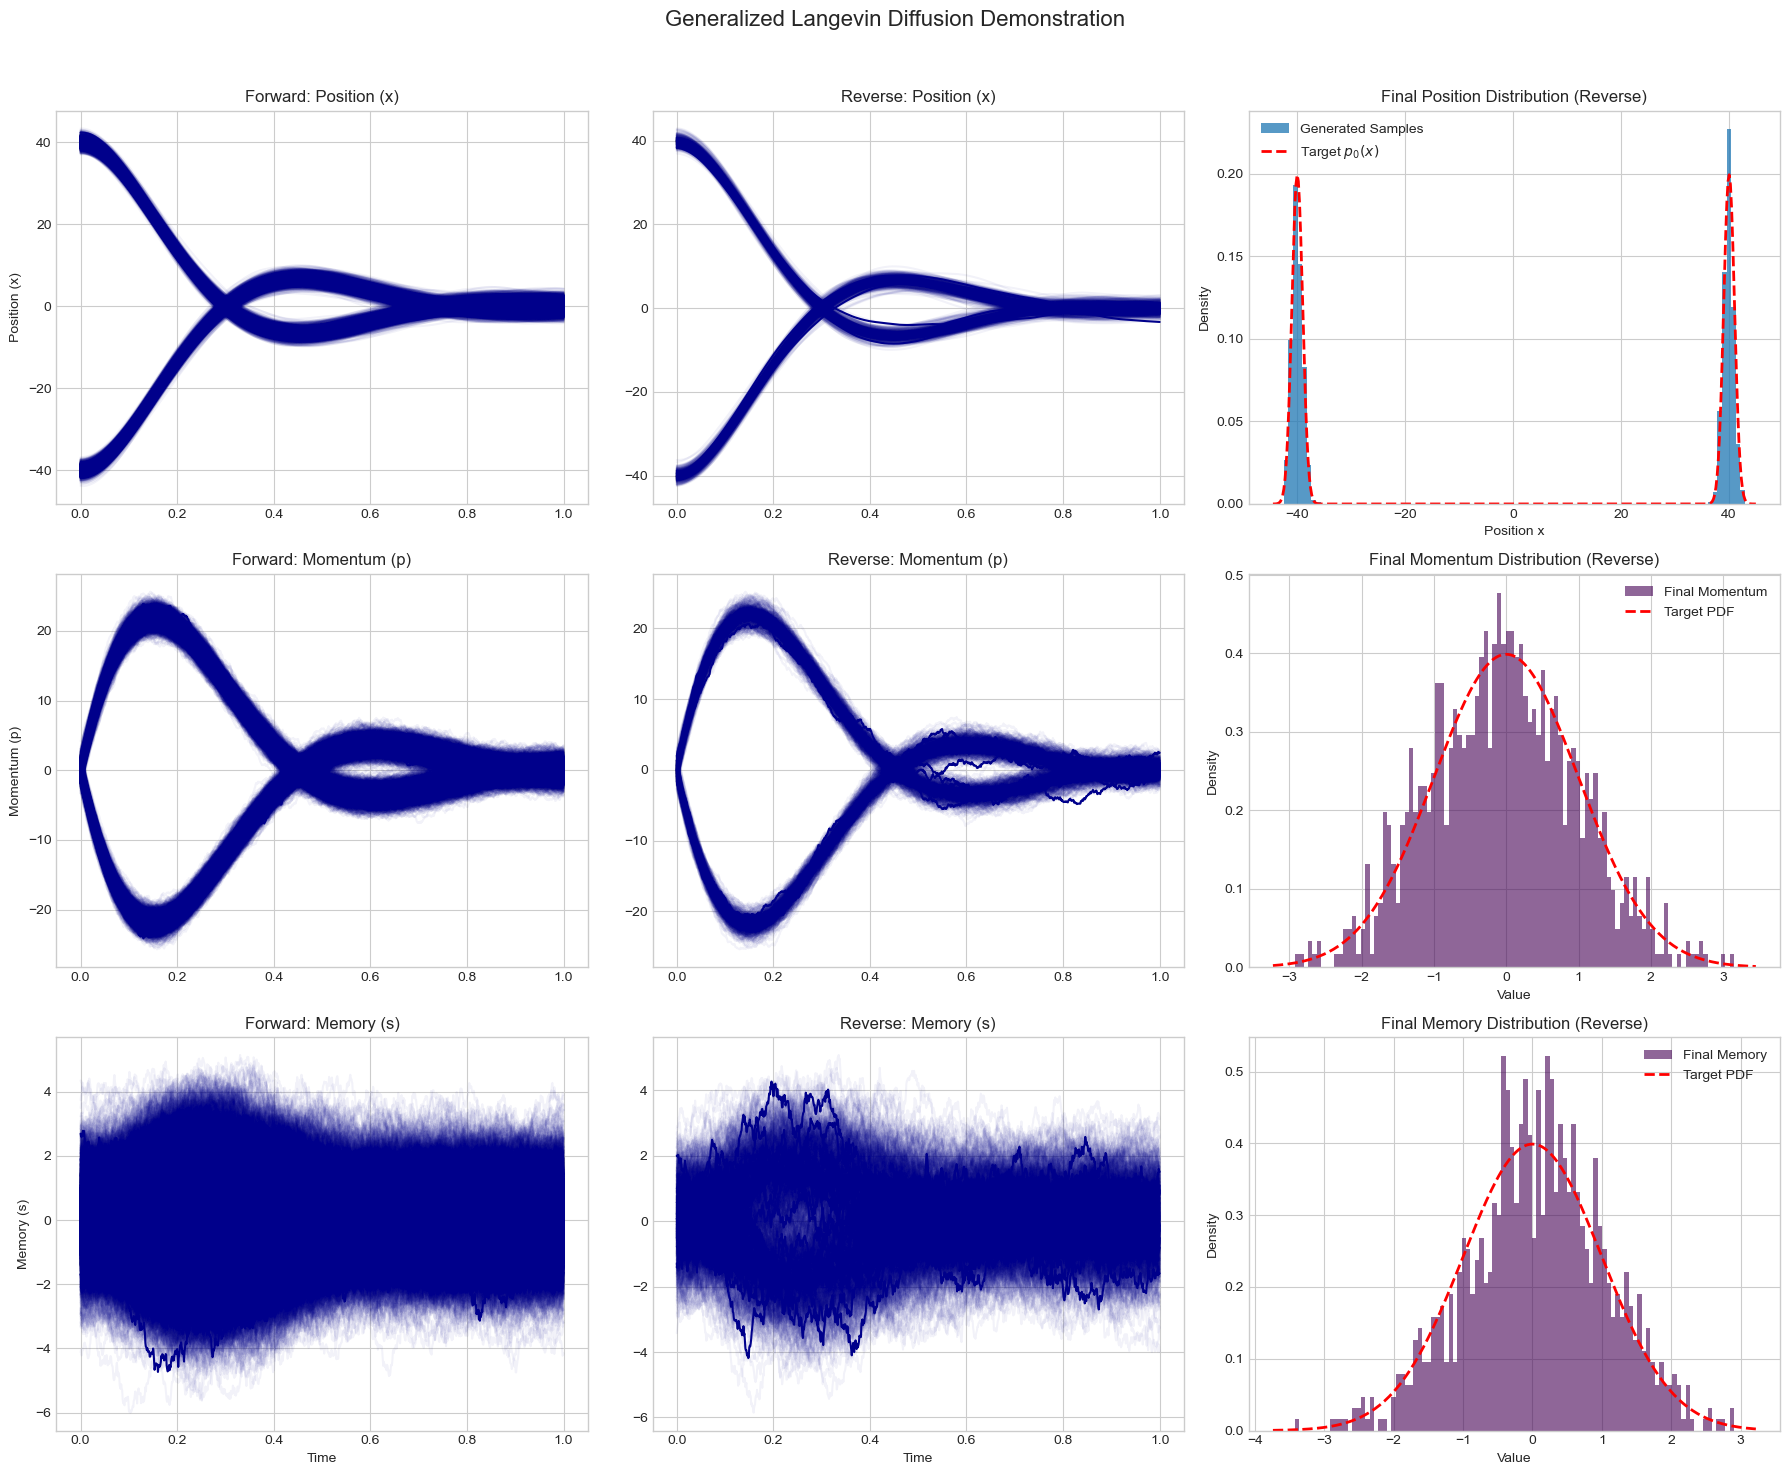

In [3]:
n_plot, n_hist = 5000, 1000
_ = gld.run_demonstration(n_plot, n_hist, score_model=None)